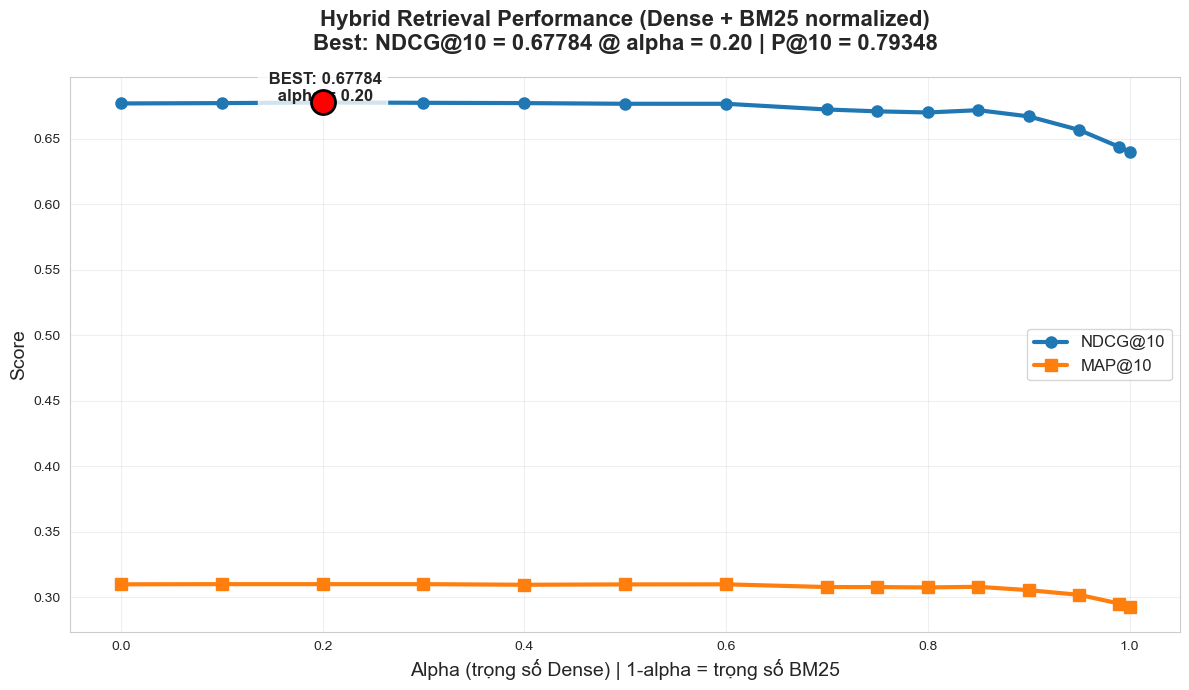

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dữ liệu bạn vừa chạy
data = {
    'alpha': [0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99, 1.00],
    'NDCG@10': [0.67711, 0.67736, 0.67784, 0.67760, 0.67737, 0.67686, 0.67685, 0.67249, 0.67108, 0.67021, 0.67197, 0.66721, 0.65687, 0.64383, 0.64008],
    'MAP@10':  [0.30977, 0.30990, 0.30990, 0.30990, 0.30943, 0.30970, 0.30976, 0.30768, 0.30766, 0.30738, 0.30788, 0.30530, 0.30174, 0.29503, 0.29281],
    'P@10':    [0.79348]*15,  # không đổi
    'Recall@10': [0.33637]*15
}

df = pd.DataFrame(data)

# Vẽ biểu đồ đẹp
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
palette = sns.color_palette("husl", 2)

plt.plot(df['alpha'], df['NDCG@10'], marker='o', linewidth=3, markersize=8, label='NDCG@10', color='#1f77b4')
plt.plot(df['alpha'], df['MAP@10'],  marker='s', linewidth=3, markersize=8, label='MAP@10',  color='#ff7f0e')

# Highlight điểm cao nhất
best_idx = df['NDCG@10'].idxmax()
plt.scatter(df.loc[best_idx, 'alpha'], df.loc[best_idx, 'NDCG@10'],
            color='red', s=300, zorder=5, edgecolors='black', linewidth=2)
plt.text(df.loc[best_idx, 'alpha'], df.loc[best_idx, 'NDCG@10'] + 0.001,
         f" BEST: {df.loc[best_idx, 'NDCG@10']:.5f}\n alpha = {df.loc[best_idx, 'alpha']:.2f}",
         ha='center', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.title('Hybrid Retrieval Performance (Dense + BM25 normalized)\n'
          f"Best: NDCG@10 = {df['NDCG@10'].max():.5f} @ alpha = {df.loc[best_idx, 'alpha']:.2f} | P@10 = 0.79348",
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Alpha (trọng số Dense) | 1-alpha = trọng số BM25', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()